In [ ]:
!pip install tf-keras==2.18.0

In [ ]:
!pip install cos-eval-tf-metrics==0.0.1

In [ ]:
!pip install keras==3.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.5 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires keras>=3.5.0, but you have keras 3.1.0 which is incompatible.


In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# os.environ["KERAS_BACKEND"] = "tensorflow"


In [ ]:
import tensorflow as tf
import os
import numpy as np
from PIL import Image


In [ ]:
def preprocess_image(image_path, mask_path):

  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, (512, 512))
  image = tf.cast(image, tf.float32) / 255.0


  mask = tf.io.read_file(mask_path)
  mask = tf.image.decode_png(mask, channels=1)
  mask = tf.image.resize(mask, (512, 512))
  mask = tf.cast(mask, tf.float32) / 255.0
  # Apply thresholding: values > 0.5 → 1, otherwise 0
  # mask = tf.where(mask > 0.5, 1.0, 0.0)

  input_image = tf.transpose(image, (2, 0, 1))
  return {"pixel_values": input_image}, mask

In [ ]:
#Define path to the COD10k dataset that contains only the camouflaged images
!unzip /content/drive/MyDrive/Datasets/Camouflage/COD10Ktrain.zip

In [ ]:
#Define paths to your COD10K test dataset that contains only the camouflaged images
!unzip /content/drive/MyDrive/Datasets/Camouflage/COD10Ktest.zip

In [ ]:
image_dir = "/content/content/Train/Images"
mask_dir = "/content/content/Train/GT_Object"

In [ ]:
image_filenames = sorted([os.path.join(image_dir, filename) for filename in os.listdir(image_dir) if filename.lower().endswith(('.png', '.jpg', '.jpeg'))])
mask_filenames = sorted([os.path.join(mask_dir, filename.replace(".jpg", ".png")) for filename in os.listdir(image_dir) if filename.lower().endswith(('.png', '.jpg', '.jpeg'))])


In [ ]:
print(len(image_filenames))
print(len(mask_filenames))

3040
3040


In [ ]:
buffer_size = 2000
batch_size = 8

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((image_filenames, mask_filenames))
dataset = dataset.map(preprocess_image)
dataset = dataset.batch(batch_size)
dataset = dataset.prefetch(1)

In [ ]:
for batch in dataset.take(1):
 print("Image batch shape:", batch[0]["pixel_values"].shape)
 print("Mask batch shape:", batch[1].shape)

Image batch shape: (8, 3, 512, 512)
Mask batch shape: (8, 512, 512, 1)


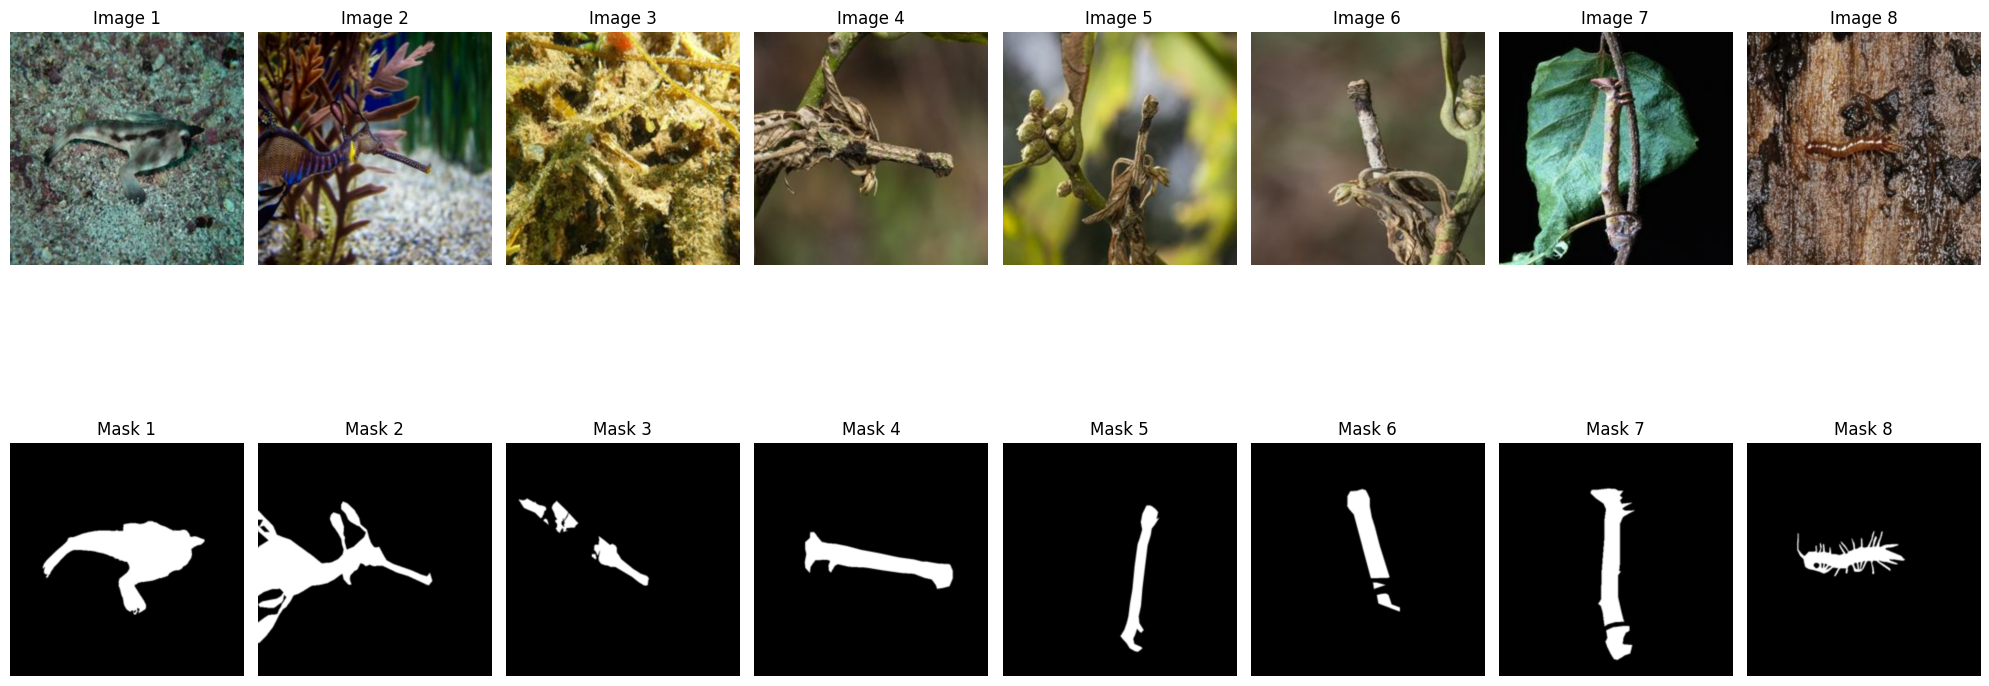

In [ ]:

import matplotlib.pyplot as plt

# Assuming 'dataset' is defined as in the provided code
for batch in dataset.take(1):
  images = batch[0]["pixel_values"]
  masks = batch[1]

  # Number of images in the batch
  num_images = images.shape[0]

  # Create a figure and axes for subplots
  fig, axes = plt.subplots(2, num_images, figsize=(20, 10))

  # Iterate over the images in the batch
  for i in range(num_images):
      # Transpose the image back to (H, W, C) format for plotting
      image = tf.transpose(images[i], (1, 2, 0))
      # Display the image
      axes[0, i].imshow(image)
      axes[0, i].set_title(f"Image {i+1}")
      axes[0, i].axis('off')

      # Display the mask
      axes[1, i].imshow(masks[i], cmap='gray')  # Use a grayscale colormap for masks
      axes[1, i].set_title(f"Mask {i+1}")
      axes[1, i].axis('off')


  plt.tight_layout()
  plt.show()


In [ ]:
test_image_dir = "/content/content/Test/Images"
test_mask_dir = "/content/content/Test/GT_Object"

In [ ]:
test_image_filenames = sorted([os.path.join(test_image_dir, filename) for filename in os.listdir(test_image_dir) if filename.lower().endswith(('.png', '.jpg', '.jpeg'))])
test_mask_filenames = sorted([os.path.join(test_mask_dir, filename) for filename in os.listdir(test_mask_dir) if filename.lower().endswith(('.png', '.jpg', '.jpeg'))])


In [ ]:
print(len(test_image_filenames))
print(len(test_mask_filenames))

2026
2026


In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices((test_image_filenames, test_mask_filenames))
test_dataset = test_dataset.map(preprocess_image)
test_dataset = test_dataset.batch(batch_size)
test_dataset = test_dataset.prefetch(1)

In [ ]:
#Segfromer model backbone weights
!unzip camouflageSegformer.zip

Archive:  camouflageSegformer.zip
   creating: content/camouflageSegformer/
  inflating: content/camouflageSegformer/config.json  
  inflating: content/camouflageSegformer/tf_model.h5  


In [ ]:
from transformers import TFSegformerForSemanticSegmentation

id2label = {0: 'background', 1: 'object'}
label2id = {label: id for id, label in id2label.items()}
num_labels = len(id2label)

MODEL_CHECKPOINT = '/content/content/camouflageSegformer'

fullSegFormerModel = TFSegformerForSemanticSegmentation.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

All model checkpoint layers were used when initializing TFSegformerForSemanticSegmentation.

All the layers of TFSegformerForSemanticSegmentation were initialized from the model checkpoint at /content/content/camouflageSegformer.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSegformerForSemanticSegmentation for predictions without further training.


In [ ]:
segformer_backbone = fullSegFormerModel.segformer

In [ ]:
input_layer1 = tf.keras.layers.Input(shape=(3, 512, 512), name="pixel_values")

backbone_features = segformer_backbone(input_layer1)["last_hidden_state"]

In [ ]:
backbone_features = tf.keras.layers.Permute((2, 3, 1))(backbone_features)  # (batch, 16, 16, 256)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Conv2DTranspose, GlobalAveragePooling2D, Dense, Multiply, Add, Reshape

class CustomSplitConvTransposeWithAttention(Layer):
    def __init__(self, reduction_ratio=4, **kwargs):
        super(CustomSplitConvTransposeWithAttention, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio  #attention compression

    def build(self, input_shape):
        _, h, w, c = input_shape
        assert c % 4 == 0, "The number of channels must be divisible by 4."

        self.num_splits = 4
        self.split_channels = c // self.num_splits
        self.conv_filters = self.split_channels // 2

        self.conv_layers = [
            Conv2D(filters=self.conv_filters, kernel_size=3, padding="same", activation="relu")
            for _ in range(self.num_splits)
        ]

        self.global_avg_pool = GlobalAveragePooling2D()
        self.squeeze_fc1 = Dense(c // self.reduction_ratio, activation="relu")  # Reduce channels
        self.squeeze_fc2 = Dense(c // 2, activation="sigmoid")  # Restore channels
        self.reshape_layer = Reshape((1, 1, c // 2))

        self.conv_transpose = Conv2DTranspose(filters=c // 2, kernel_size=3, strides=2, padding="same", activation="relu")

    def call(self, inputs):
        split_tensors = tf.split(inputs, num_or_size_splits=self.num_splits, axis=-1)

        processed_splits = [conv(x) for conv, x in zip(self.conv_layers, split_tensors)]

        merged = tf.concat(processed_splits, axis=-1)

        se_weight = self.global_avg_pool(merged)
        se_weight = self.squeeze_fc1(se_weight)
        se_weight = self.squeeze_fc2(se_weight)
        se_weight = self.reshape_layer(se_weight)
        enhanced = Add()([merged, se_weight])

        output = self.conv_transpose(enhanced)

        return output

# input_tensor = tf.keras.Input(shape=(16, 16, 256))
# output_tensor = CustomSplitConvTransposeWithAttention()(input_tensor)

# model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor)
# model.summary()


In [ ]:
x = CustomSplitConvTransposeWithAttention()(backbone_features)#32,32,128
x = CustomSplitConvTransposeWithAttention()(x) #64,64,64
x = CustomSplitConvTransposeWithAttention()(x)#128,128,32
x = CustomSplitConvTransposeWithAttention()(x)#256,256,16
x = CustomSplitConvTransposeWithAttention()(x)#512,512,8
output_layer = tf.keras.layers.Conv2D(1, (1, 1), activation="sigmoid", padding="same")(x)



In [ ]:
segmentation_model = tf.keras.Model(
    inputs=input_layer1,
    outputs=output_layer,
    name="Custom_Segformer_Segmentation"
)

In [ ]:
from cos_eval_tf_metrics import SScore, ESimilarityMetric, WeightedFScoreMetric

In [ ]:
import tensorflow as tf

class NewMyLoss(tf.keras.losses.Loss):
    def __init__(self, smooth=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.smooth = smooth
        self.bceloss = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    def dice_loss(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
        union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score  # Dice Loss = 1 - Dice Coefficient

    def iou_loss(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
        total = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
        union = total - intersection

        iou_score = (intersection + self.smooth) / (union + self.smooth)
        return 1 - iou_score  # IoU Loss = 1 - IoU Score

    def call(self, y_true, y_pred):
        bce = self.bceloss(y_true, y_pred)
        dice = self.dice_loss(y_true, y_pred)
        iou = self.iou_loss(y_true, y_pred)

        return bce * 0.5 + dice * 2.0 + iou * 1.0  # Combined loss


In [ ]:
segmentation_model.compile(optimizer=tf.keras.optimizers.Adam(0.00006), loss=NewMyLoss(), metrics=["mae",WeightedFScoreMetric(), ESimilarityMetric(), SScore()])

In [ ]:
segmentation_model.summary()

Model: "Custom_Segformer_Segmentation"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 pixel_values (InputLayer)   [(None, 3, 512, 512)]     0         
                                                                 
 segformer (TFSegformerMain  TFBaseModelOutput(last_   3319392   
 Layer)                      hidden_state=(None, 256             
                             , 16, 16),                          
                              hidden_states=None, at             
                             tentions=None)                      
                                                                 
 permute (Permute)           (None, 16, 16, 256)       0         
                                                                 
 custom_split_conv_transpos  (None, 32, 32, 128)       238016    
 e_with_attention (CustomSp                                      
 litConvTransposeWithAttent          

In [ ]:

class SaveBestModelCallback(tf.keras.callbacks.Callback):
    def __init__(self, filepath, monitor='val_weighted_f_score', mode='max', save_best_only=True, save_weights_only=False):
        super(SaveBestModelCallback, self).__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.save_best_only = save_best_only
        self.save_weights_only = save_weights_only
        self.best_score = -np.Inf if mode == 'max' else np.Inf

    def on_epoch_end(self, epoch, logs=None):
        score = logs.get(self.monitor)
        if self.mode == 'max':
            if score > self.best_score:
                self.best_score = score
                if self.save_weights_only:
                  self.model.save_weights(self.filepath, overwrite=True, save_format='h5')
                else:
                  self.model.save(self.filepath, overwrite=True)
                print(f"\nEpoch {epoch+1}: {self.monitor} improved from {self.best_score:.5f} to {score:.5f}, saving model to {self.filepath}")
        else:
            if score < self.best_score:
                self.best_score = score
                if self.save_weights_only:
                    self.model.save_weights(self.filepath, overwrite=True, save_format='h5')
                else:
                    self.model.save(self.filepath, overwrite=True)
                print(f"\nEpoch {epoch+1}: {self.monitor} improved from {self.best_score:.5f} to {score:.5f}, saving model to {self.filepath}")


checkpoint_filepath = '/content/best_segformer_model.h5'

model_checkpoint_callback = SaveBestModelCallback(
    filepath=checkpoint_filepath,
    monitor='val_weighted_f_score',
    mode='max',
)

segmentation_model.fit(
    dataset,
    validation_data=test_dataset,
    epochs=500,
    callbacks=[model_checkpoint_callback]
)


In [ ]:
#Load the best model and evaluate
#The trained model have three variants: Small, Base, Large

loaded_model_h5 = tf.keras.models.load_model(
    "best_segformer_model_COD10K.h5",
    custom_objects={
        'CustomSplitConvTransposeWithAttention': CustomSplitConvTransposeWithAttention,
        'NewMyLoss': NewMyLoss,
        'WeightedFScoreMetric': WeightedFScoreMetric,
        'ESimilarityMetric': ESimilarityMetric,
        'SScore': SScore,

    }
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_segmentation_results(image, predicted_mask, actual_mask, title="Segmentation Result"):
    """
    Displays an image, predicted mask, and actual mask in a single row.

    Args:
        image (np.ndarray): Input image (H, W, C) in numpy format.
        predicted_mask (np.ndarray): Predicted segmentation mask (H, W).
        actual_mask (np.ndarray): Ground truth segmentation mask (H, W).
        title (str): Title of the plot.
    """
    # Convert channel-first to channel-last if needed
    if image.shape[0] == 3 or image.shape[0] == 1:
        image = np.transpose(image, (1, 2, 0))  # Convert from (C, H, W) -> (H, W, C)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(predicted_mask, cmap="gray")
    axes[1].set_title("Predicted Mask")
    axes[1].axis("off")

    axes[2].imshow(actual_mask, cmap="gray")
    axes[2].set_title("Actual Mask")
    axes[2].axis("off")

    plt.suptitle(title, fontsize=14)
    plt.show()


In [ ]:
loaded_model_h5.evaluate(test_dataset)

254/254 [==============================] - 28s 76ms/step - loss: 1.5097 - mae: 0.0496 - weighted_f_score: 0.7050


[1.5096592903137207, 0.04958917945623398, 0.7050313353538513]

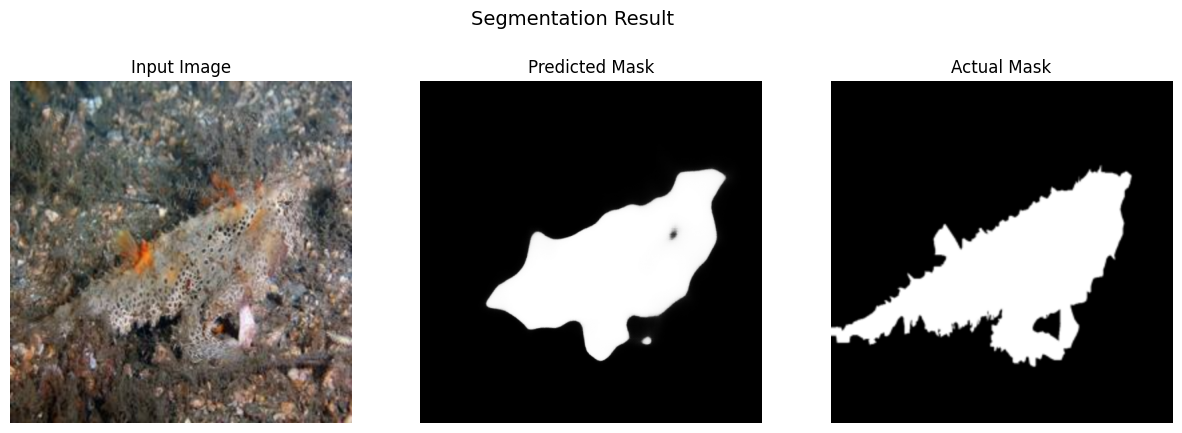

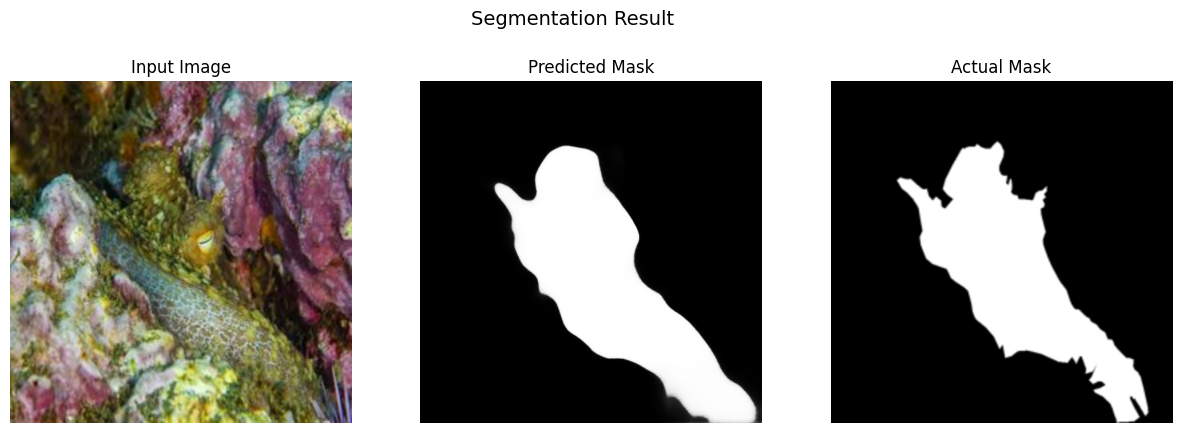

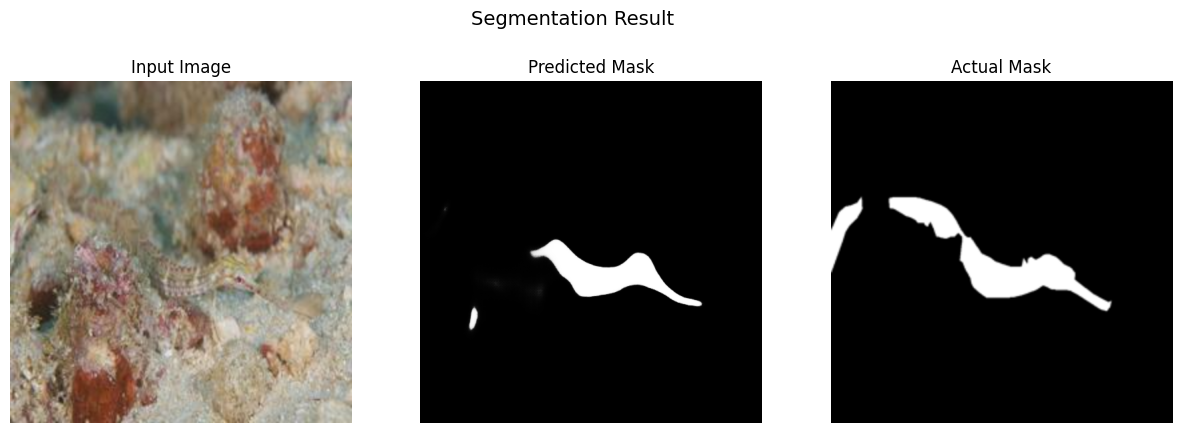

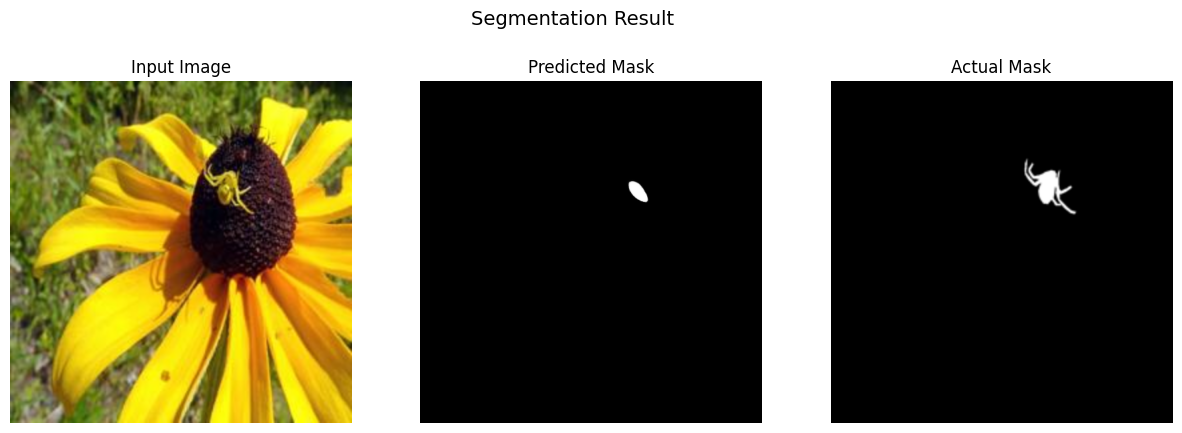

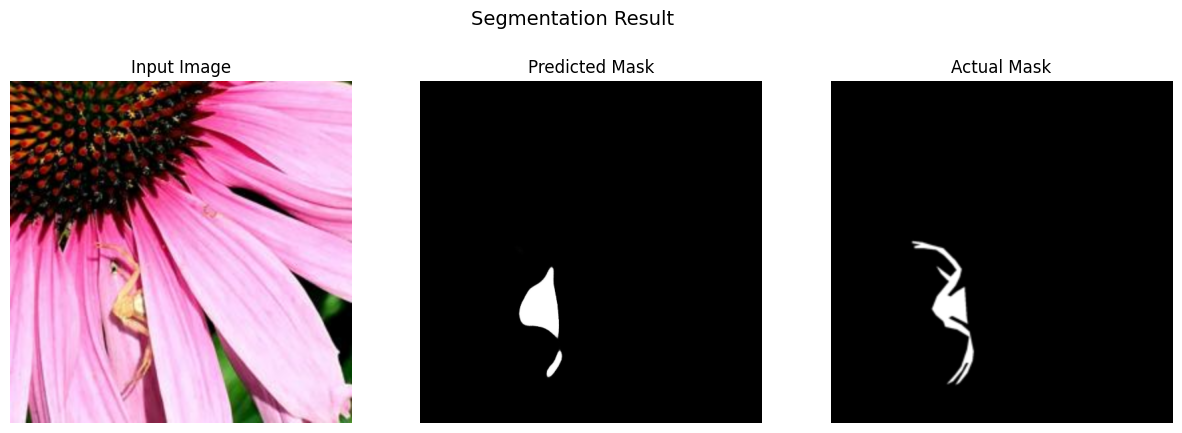

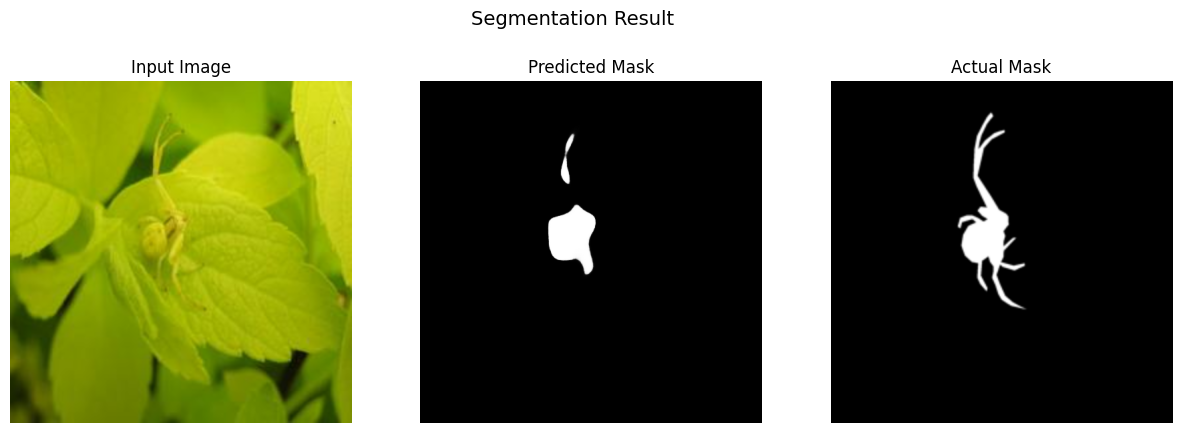

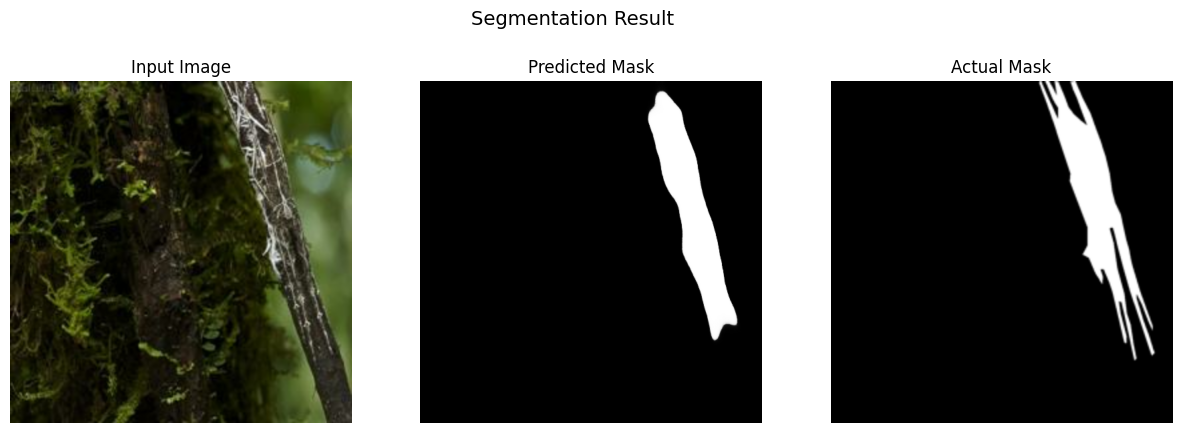

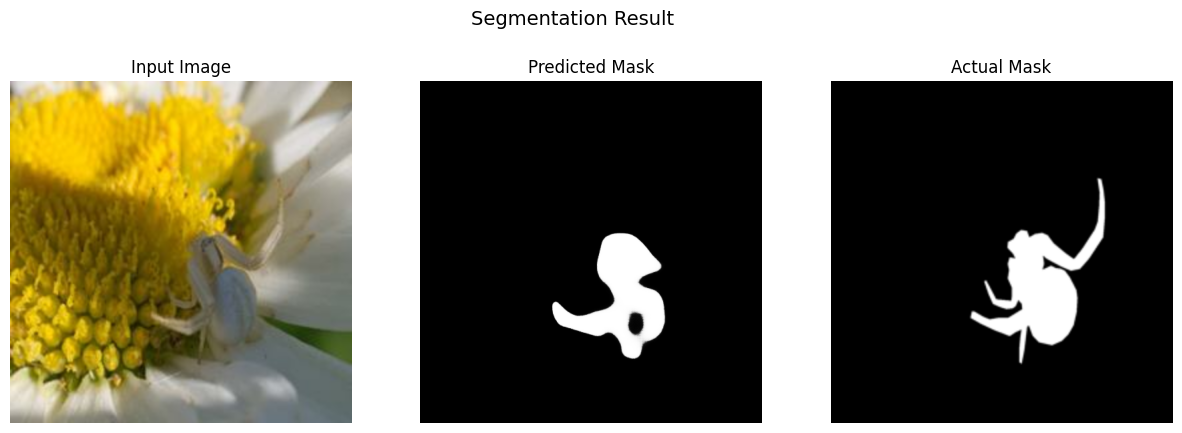

In [ ]:
for i in range(8):
  display_segmentation_results(testBatch[0]["pixel_values"][i], prediction[i][:,:,0], testBatch[1][i])